In [1]:
import sys

custom_module_path = "/home/rebeccaz/Github/vampires_calibration"
sys.path.append(custom_module_path)

import instruments as inst
import copy
import numpy as np
import json

# Step 1.a): Reading in csv - extracting single diffs and sums and configurations

In [2]:
file_path = "/home/rebeccaz/Github/vampires_calibration/data/20230914_processed_table.csv"
wavelength_string = 670
obs_mode = "MBI"

interleaved_values, interleaved_stds, configuration_list = inst.read_csv(file_path, 
    obs_mode = obs_mode, obs_filter = wavelength_string)
print("Interleaved Values")
print("Length: ", len(interleaved_values))
print(interleaved_values)
print("Interleaved Stds")
print("Length: ", len(interleaved_stds))
print(interleaved_stds[0 : 10])
print("Configuration List")
print("Length: ", len(configuration_list))
print(configuration_list)

print(interleaved_stds[0])

Interleaved Values
Length:  320
[  4891.    12895.5   -8596.    13342.5    1190.5   12976.    -5411.5
  13045.    -6623.5   13368.5    2486.    12814.   -12740.5   13944.
   9496.5   12967.5  -13235.    13903.    11358.    13094.5   -8040.5
  13293.     7342.5   13117.5    -674.    12906.      334.5   13393.
   3112.    12875.5   -3963.    13650.     4450.    13125.5   -6885.5
  13580.     6726.5   12994.5   -9906.    13737.5    2201.    13172.5
  -6372.5   13278.    -6036.    13547.5    1799.5   12976.5  -12123.5
  14053.     8802.    12981.   -12333.5   13903.    10326.    13109.5
  -7081.    13226.     6317.    13089.     -227.    12805.      -70.5
  13321.5    1057.    13329.    -2102.5   13579.     8027.5   13096.5
  -9776.    13947.5    9101.    13241.   -12201.    13999.     3880.5
  13327.5   -8014.5   13505.5   -4793.5   13695.5     477.5   13135.5
 -10556.    14132.     7209.5   12967.   -10266.    13911.     8276.
  12972.    -4663.    13153.     3708.25  13091.    -2852.   

In [3]:
%%timeit

import copy


copy.deepcopy(interleaved_values)

3.06 µs ± 41 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


# Step 1.b) - Make plot of existing values as double diffs and sums

# Step 2: Creating a system Mueller matrix object

In [4]:
# Loading in previous fit from vampires_calibration
filename = "/home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/675-50_restrictive_HWP_FLC_with_IMR_offset_with_dichroic_best_fit_old_fit_values.txt"
with open(filename, "r") as f:
    past_fit = json.load(f)
past_fit.pop("wollaston", None)
past_fit.setdefault("image_rotator", {})
past_fit["image_rotator"].setdefault("delta_theta", 0.0)

print(past_fit)

theta_pol = past_fit["lp"]["theta"]
delta_HWP = past_fit["hwp"]["phi"] 
offset_HWP = past_fit["hwp"]["delta_theta"]
delta_derot = past_fit["image_rotator"]["phi"] 
offset_derot = past_fit["image_rotator"]["delta_theta"]
delta_opts = past_fit["optics"]["phi"]
epsilon_opts = past_fit["optics"]["epsilon"]
rot_opts = past_fit["optics"]["theta"]
delta_FLC = past_fit["flc"]["phi"] 
rot_FLC = past_fit["flc"]["delta_theta"]
em_gain = 1.19 # from EM gain measurements

# Based on values in Six_And_Eleven_Parameter_Model_Best_MCMC_and_Scipy_Fits Google Sheets - having zeros for angles that're too large
# theta_pol = 0
# delta_HWP = 0.451  # Add your actual delta_HWP value
# offset_HWP = -2.642  # Add your actual offset_HWP value
# delta_derot = 0.32  # Add your actual delta_derot value
# offset_derot = 0  # Add your actual offset_derot value
# delta_opts = 0  # Add your actual delta_opts value
# epsilon_opts = 0  # Add your actual epsilon_opts value
# rot_opts = 0  # Add your actual rot_opts value
# delta_FLC = 0.5  # Add your actual delta_FLC value
# rot_FLC = 0  # Add your actual rot_FLC value
# em_gain = 1.2  # Add your actual em_gain value

# NOTE: Components must be listed downstream to upstream
# Define the instrument configuration as a system dictionary
system_dict = {
    "components": {
        "wollaston": {
            "type": "wollaston_prism_function",
            "properties": {"beam": "o", "transmission_ratio": em_gain},
        },
        "dichroic": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": 0, "epsilon": 0, "theta" : 0},
        },
        "flc": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_FLC, "theta": 0, "delta_theta": rot_FLC},
        },
        "optics": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": delta_opts, "epsilon": epsilon_opts, "theta": rot_opts},
        },
        "image_rotator": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_derot, "theta": 0, "delta_theta": offset_derot},
        },
        "hwp": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_HWP, "theta": 0, "delta_theta": offset_HWP},
        },
        "lp": {
            "type": "general_linear_polarizer_function_with_theta",
            "properties": {"theta": theta_pol},
        }
    }
}

{'dichroic': {'phi': 0.048850124506731624, 'epsilon': 0.788816165342153, 'theta': 11.229522999426173}, 'flc': {'phi': 3.232399009420191, 'delta_theta': 4.999886322731815}, 'optics': {'phi': -1.1868279658610281, 'epsilon': 0.0033666836034024735, 'theta': 22.7304607472055}, 'image_rotator': {'phi': 2.052555064274884, 'delta_theta': -1.0}, 'hwp': {'phi': 2.8961445406582538, 'delta_theta': -0.14863092826865115}, 'lp': {'theta': 2.6654401390468028}}


In [5]:
# Converting system dictionary into system Mueller Matrix object

system_mm = inst.generate_system_mueller_matrix(system_dict)
print(system_mm.evaluate())

[[0.52211553 0.51985726 0.04850831 0.        ]
 [0.52211553 0.51985726 0.04850831 0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]]


# Step 4: Creating a dictionary of p0 starting guesses

{'dichroic': {'phi': 0.048850124506731624, 'epsilon': 0.788816165342153, 'theta': 11.229522999426173}, 'flc': {'phi': 3.232399009420191, 'delta_theta': 4.999886322731815}, 'optics': {'phi': -1.1868279658610281, 'epsilon': 0.0033666836034024735, 'theta': 22.7304607472055}, 'image_rotator': {'phi': 2.052555064274884, 'delta_theta': -1.0}, 'hwp': {'phi': 2.8961445406582538, 'delta_theta': -0.14863092826865115}, 'lp': {'theta': 2.6654401390468028}}
logl value: 78494.4346813123


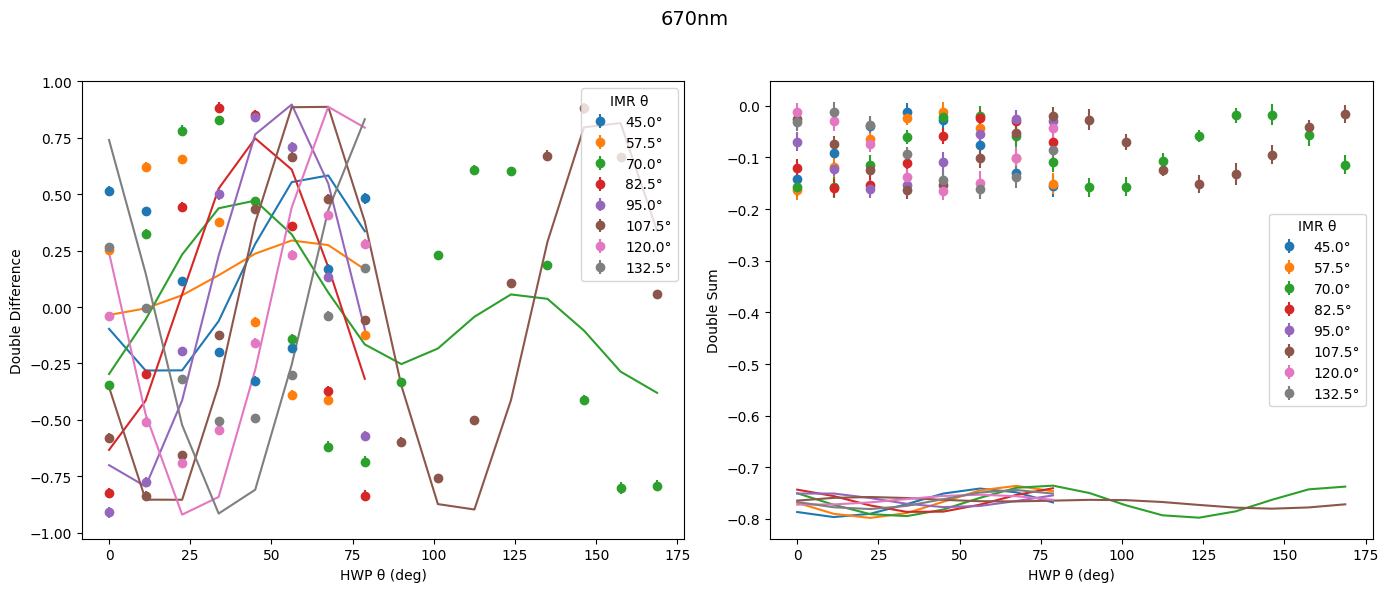

In [6]:
# Fittin for all parameters
p0 = past_fit

print(p0)

p0_values, p0_keywords = inst.parse_configuration(p0)
s_in = np.array([1, 0, 0, 0])
logl_value = inst.logl(p0_values, p0_keywords, system_mm, interleaved_values, interleaved_stds, configuration_list,
    s_in=s_in, logl_function=None, process_dataset=inst.process_dataset, process_errors=inst.process_errors, 
    process_model=inst.process_model)
print("logl value: " + str(logl_value))

# TODO: Add an initial plot block here
# Plotting intial plot
updated_system_mm = inst.update_system_mm(p0_values, p0_keywords, system_mm)
model = inst.model(p0_values, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)

# Step 5: Running minimize_system_Mueller_matrix iteratively

Before p0: {'dichroic': {'phi': 0.048850124506731624, 'epsilon': 0.788816165342153, 'theta': 11.229522999426173}, 'flc': {'phi': 3.232399009420191, 'delta_theta': 4.999886322731815}, 'optics': {'phi': -1.1868279658610281, 'epsilon': 0.0033666836034024735, 'theta': 22.7304607472055}, 'image_rotator': {'phi': 2.052555064274884, 'delta_theta': -1.0}, 'hwp': {'phi': 2.8961445406582538, 'delta_theta': -0.14863092826865115}, 'lp': {'theta': 2.6654401390468028}}
Iteration #: 1
logl_value: 54.14550408734843
Best Fit Parameters: [ 1.41390383e-01  2.37272216e-01  4.49573420e+01  3.03819853e+00
  3.22048158e-01 -6.31709321e-01  1.83581362e-03 -7.97989132e+01
  1.99501109e+00 -1.00000000e+00  2.87523030e+00  3.20317632e-01
  4.60761882e+00]


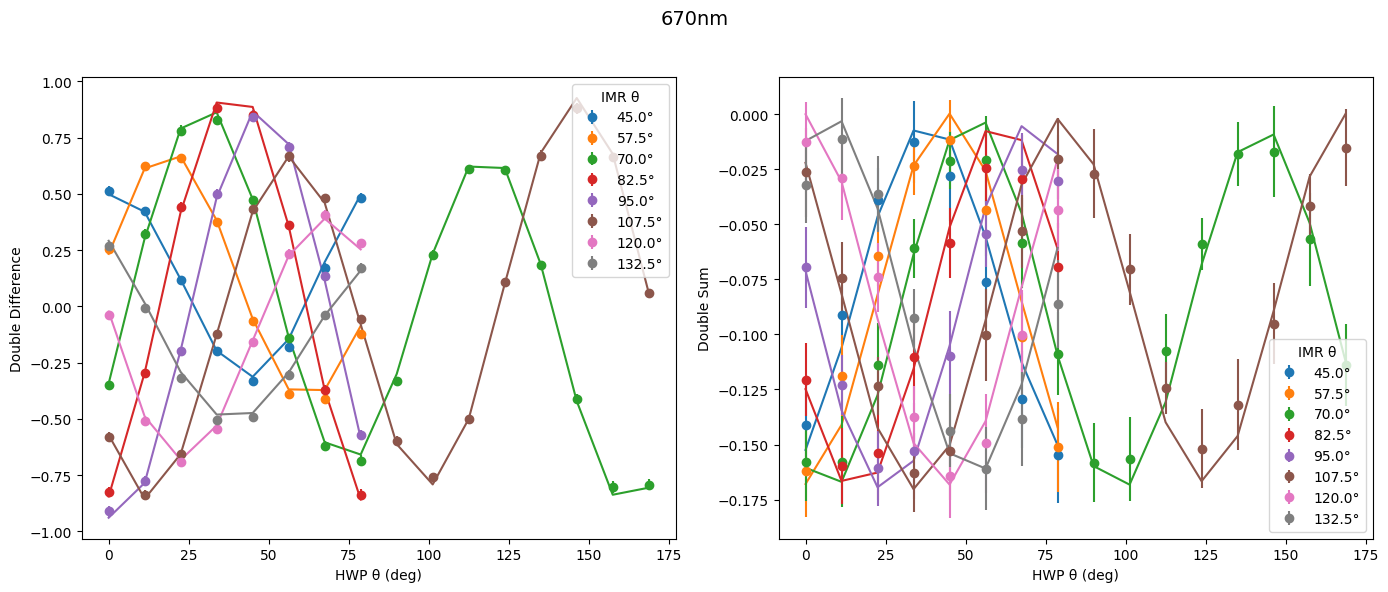

After p0: {'dichroic': {'phi': 0.1413903826205566, 'epsilon': 0.23727221644690355, 'theta': 44.95734202993799}, 'flc': {'phi': 3.0381985335491297, 'delta_theta': 0.3220481579572625}, 'optics': {'phi': -0.6317093206644575, 'epsilon': 0.0018358136206657449, 'theta': -79.79891315967643}, 'image_rotator': {'phi': 1.9950110921651927, 'delta_theta': -1.0}, 'hwp': {'phi': 2.875230297333532, 'delta_theta': 0.32031763193423846}, 'lp': {'theta': 4.60761882415491}}
Before p0: {'dichroic': {'phi': 0.1413903826205566, 'epsilon': 0.23727221644690355, 'theta': 44.95734202993799}, 'flc': {'phi': 3.0381985335491297, 'delta_theta': 0.3220481579572625}, 'optics': {'phi': -0.6317093206644575, 'epsilon': 0.0018358136206657449, 'theta': -79.79891315967643}, 'image_rotator': {'phi': 1.9950110921651927, 'delta_theta': -1.0}, 'hwp': {'phi': 2.875230297333532, 'delta_theta': 0.32031763193423846}, 'lp': {'theta': 4.60761882415491}}
Iteration #: 2
logl_value: 18.513893225635115
Best Fit Parameters: [ 7.67342555e-

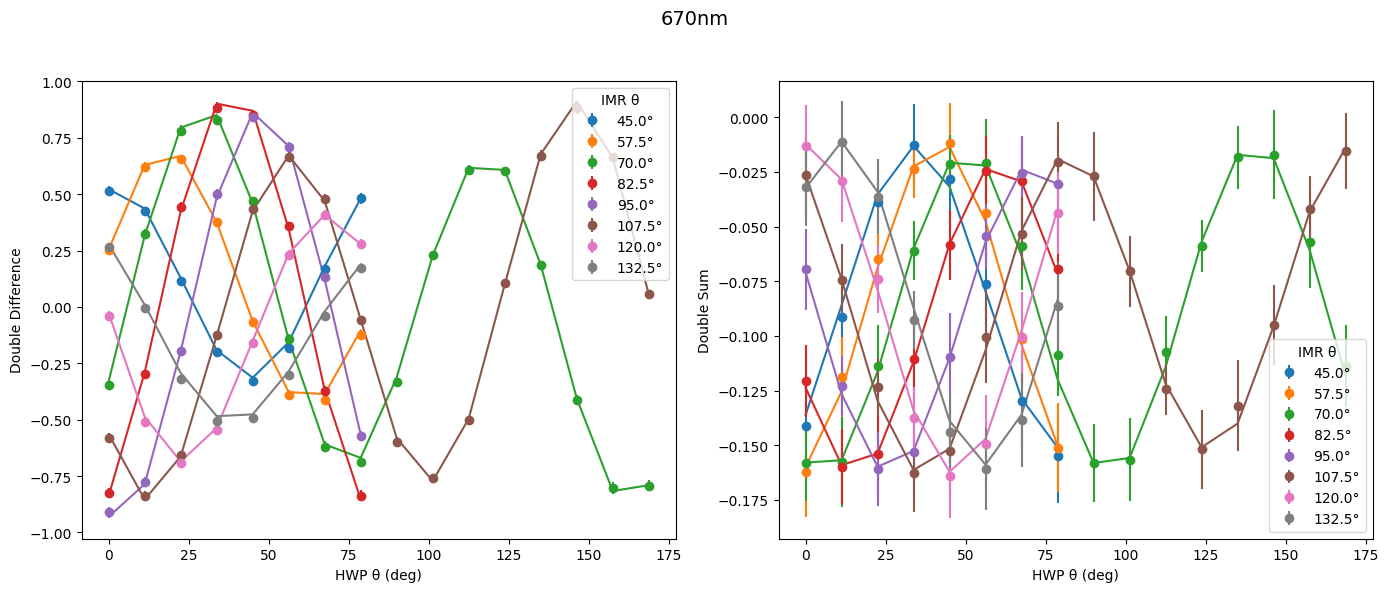

After p0: {'dichroic': {'phi': 0.07673425553087079, 'epsilon': 0.2806940020166856, 'theta': 44.91797542175385}, 'flc': {'phi': 3.1478916601635216, 'delta_theta': 0.009685941067493462}, 'optics': {'phi': -0.7841110080896434, 'epsilon': 0.004156547144015341, 'theta': -84.47426199801598}, 'image_rotator': {'phi': 2.003578999979018, 'delta_theta': -1.0}, 'hwp': {'phi': 2.8849306117122246, 'delta_theta': -1.9890535817711203}, 'lp': {'theta': -0.11379755732130747}}
Before p0: {'dichroic': {'phi': 0.07673425553087079, 'epsilon': 0.2806940020166856, 'theta': 44.91797542175385}, 'flc': {'phi': 3.1478916601635216, 'delta_theta': 0.009685941067493462}, 'optics': {'phi': -0.7841110080896434, 'epsilon': 0.004156547144015341, 'theta': -84.47426199801598}, 'image_rotator': {'phi': 2.003578999979018, 'delta_theta': -1.0}, 'hwp': {'phi': 2.8849306117122246, 'delta_theta': -1.9890535817711203}, 'lp': {'theta': -0.11379755732130747}}
Iteration #: 3
logl_value: 15.467645092614895
Best Fit Parameters: [ 8.

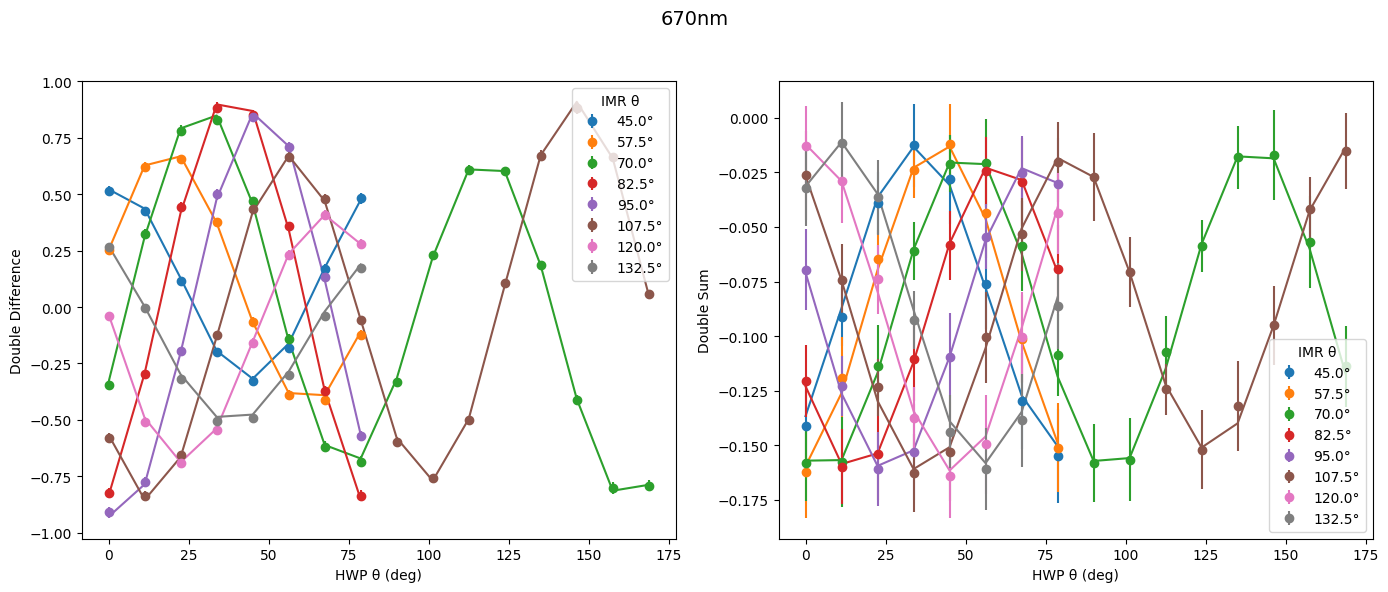

After p0: {'dichroic': {'phi': 0.08262663840152465, 'epsilon': 0.28661429206145694, 'theta': 44.93833122724104}, 'flc': {'phi': 3.1357698297416574, 'delta_theta': 0.08606522716375398}, 'optics': {'phi': -0.7735512546404737, 'epsilon': 3.54353350209987e-05, 'theta': -84.02917222562729}, 'image_rotator': {'phi': 2.0035706867309564, 'delta_theta': -1.0}, 'hwp': {'phi': 2.885038935511507, 'delta_theta': -2.5267219090675415}, 'lp': {'theta': -1.0818649643633547}}
Before p0: {'dichroic': {'phi': 0.08262663840152465, 'epsilon': 0.28661429206145694, 'theta': 44.93833122724104}, 'flc': {'phi': 3.1357698297416574, 'delta_theta': 0.08606522716375398}, 'optics': {'phi': -0.7735512546404737, 'epsilon': 3.54353350209987e-05, 'theta': -84.02917222562729}, 'image_rotator': {'phi': 2.0035706867309564, 'delta_theta': -1.0}, 'hwp': {'phi': 2.885038935511507, 'delta_theta': -2.5267219090675415}, 'lp': {'theta': -1.0818649643633547}}
Iteration #: 4
logl_value: 15.451035393080693
Best Fit Parameters: [ 8.36

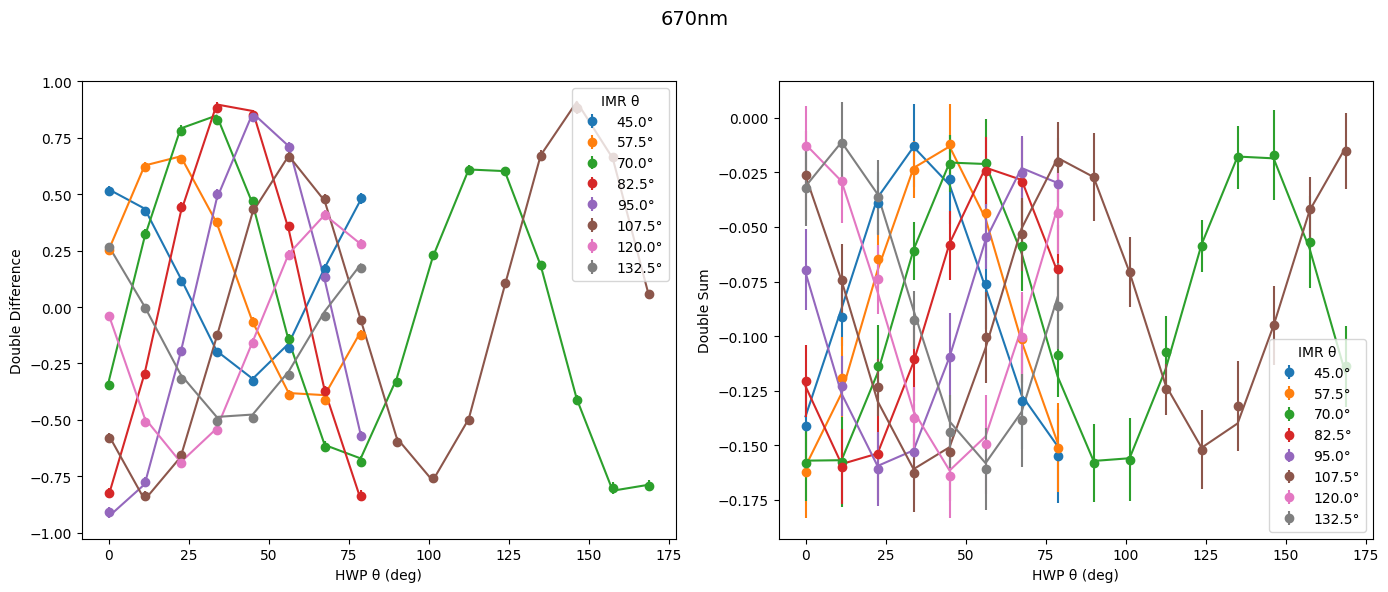

After p0: {'dichroic': {'phi': 0.08366205185586989, 'epsilon': 0.2871975670809377, 'theta': 44.93500569443836}, 'flc': {'phi': 3.133748005158858, 'delta_theta': 0.09771154994415154}, 'optics': {'phi': -0.7731070144010215, 'epsilon': 1.8947601481257727e-09, 'theta': -83.96087654196432}, 'image_rotator': {'phi': 2.0036423006039827, 'delta_theta': -1.0}, 'hwp': {'phi': 2.884926763810989, 'delta_theta': -2.5383939929540755}, 'lp': {'theta': -1.087010699372489}}


In [7]:
# Unpolarized light for s_in as there is LP in the system already
s_in = np.array([1, 0, 0, 0])
bounds_dict = {
    # "wollaston": {
    #     "transmission_ratio": (0.8, 1.2)
    # },
    "dichroic": {
        "phi": (-2 * np.pi, 2 * np.pi),
        "epsilon": (0, 1),
        "theta": (-90, 90)
    },
    "flc": {
        "phi": (0.4 * 2 * np.pi, 0.6 * 2 * np.pi),
        "delta_theta": (-5, 5)
    },
    "optics": {
        "phi": (-np.pi, np.pi),
        "epsilon": (0, 1),
        "theta": (-90, 90)
    },
    "image_rotator": {
        "phi": (-2 * np.pi, 2 * np.pi),
        "delta_theta": (-1, 1)
    },
    "hwp": {
        "phi": (
             (-2 * np.pi, 2 * np.pi)
        ),
        "delta_theta": (-5, 5)
    },
    "lp": {
        "theta": (-5, 5)
    }
}

# Now flatten the bounds in the same order as p0_keywords
p0_values, p0_keywords = inst.parse_configuration(p0)
for (comp, param), val in zip(p0_keywords, p0_values):
    lower, upper = bounds_dict[comp][param]
    if not (lower <= val <= upper):
        print(f"{comp}.{param} = {val} is outside bounds {lower} to {upper}")
bounds = [bounds_dict[comp][param] for comp, param in p0_keywords]

# Counters for iterative fitting
iteration = 1
previous_logl_value = 1000000
new_logl_value = 0

while abs(previous_logl_value - new_logl_value) > 0.01 * abs(previous_logl_value):
    print("Before p0: " + str(p0))
    if iteration > 1: 
        previous_logl_value = new_logl_value
    result, new_logl_value = inst.minimize_system_mueller_matrix(p0, system_mm, 
        interleaved_values, interleaved_stds, configuration_list, s_in = s_in,
        process_dataset = inst.process_dataset, 
        process_errors = inst.process_errors, 
        process_model = inst.process_model, bounds = bounds)
    
    # Print statements
    print("Iteration #: " + str(iteration))
    print("logl_value: " + str(new_logl_value))
    print("Best Fit Parameters: " + str(result.x))

    # Making a plot
    updated_system_mm = inst.update_system_mm(result.x, p0_keywords, system_mm)
    model = inst.model(result.x, p0_keywords, updated_system_mm, configuration_list, 
    process_model = inst.process_model)

    inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
        configuration_list, wavelength = wavelength_string)

    # Updating p0 for next time
    inst.update_p0(p0, result.x)
    print("After p0: " + str(p0))

    iteration += 1

    filename = f"/home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/{wavelength_string}_with_IMR_offset_pm_1_degree_fixed_EM_gain_with_dichroic_best_fit_old_fit_values.txt"
    with open(filename, 'w') as f:
        json.dump(p0, f, indent=4)

# Step 6: Plot model with best fit

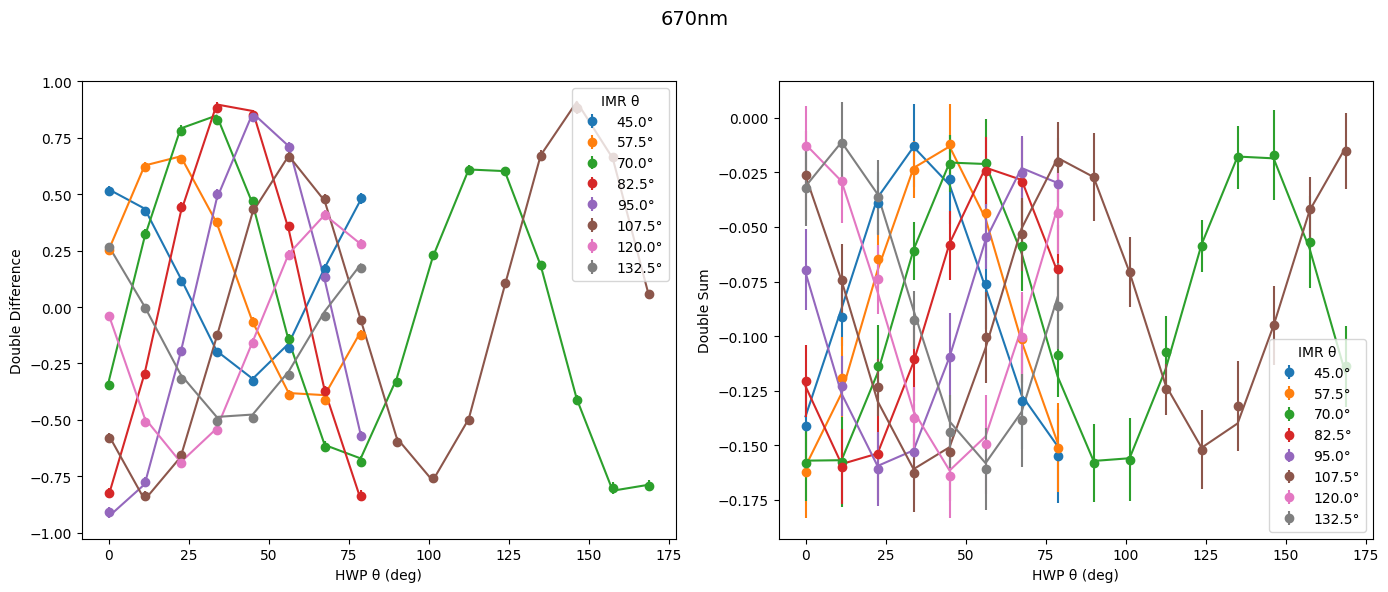

In [8]:
# Generate model with p0 keywords but scipy minimized results
# print(result.x)
# print(p0_keywords)

# Manually adjusting for a good fit
dichroic_phi = 0 # (waves)
dichroic_theta = 0 # (degrees)
# result.x = [2 * np.pi * dichroic_phi, dichroic_theta]

updated_system_mm = inst.update_system_mm(result.x, p0_keywords, system_mm)
model = inst.model(result.x, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)